# This is the codes for Quantitative Risk Management Coursework 2.
The group members are Zhengyang Li, Fiona Lemon, Thomas Pink and Jacques Zhang.

In [1]:
# This is the code implementation of Quantitive Qisk Management Coursework 2
import numpy as np
import pandas as pd
from arch.univariate import arch_model
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
from scipy.stats import chi2, norm
import statsmodels.api as sm
import seaborn as sns
import datetime

from scipy.stats import t
from scipy.stats import norm
from scipy.stats import genpareto
import scipy.integrate as integrate
from scipy.special import beta
from scipy.optimize import minimize

In [2]:
# import the data
data = pd.read_csv('QRM-2024-cw2-data.csv')

price_series = data['TSLA']
time_arr = np.array(data['Date'][1:])
time_arr_datetime = pd.to_datetime(time_arr)

# locate the index of 2021-11-26
index = np.where(time_arr_datetime == np.datetime64('2021-11-26'))[0][0]

# compute the log return vector
return_series = -100 * np.log(price_series).diff()
x = return_series.dropna() # get rid of the NaN component

# separate the training and testing data
x_training = x[0:index]
x_training_arr = np.array(x_training)
x_testing = x[index:]
x_testing_arr = np.array(x_testing)

prices_arr = np.array(price_series)[1:index]

# obtain the time arrays for training and testing
time_training = time_arr_datetime[0:index]
time_testing = time_arr_datetime[index:]

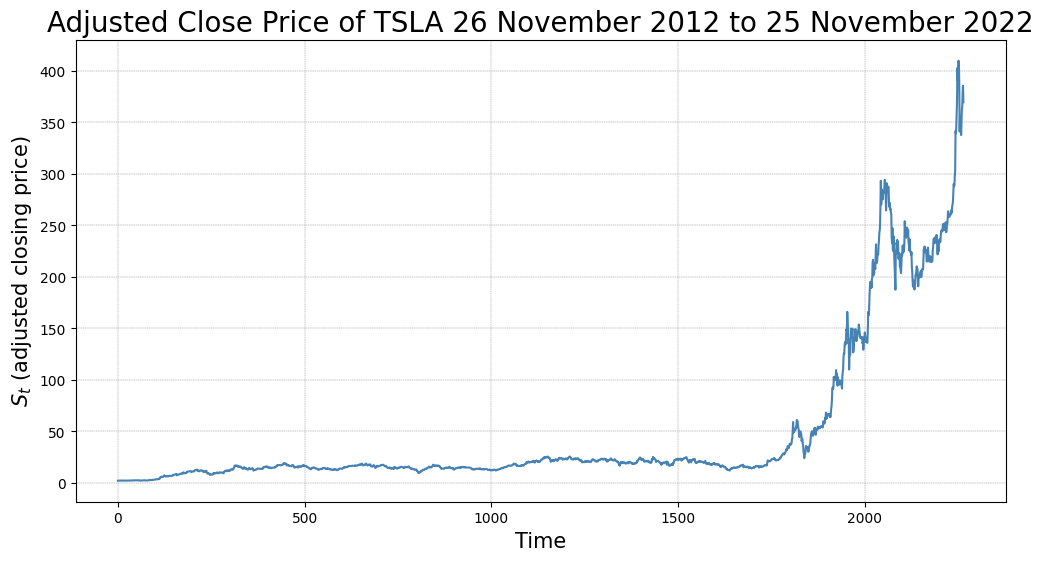

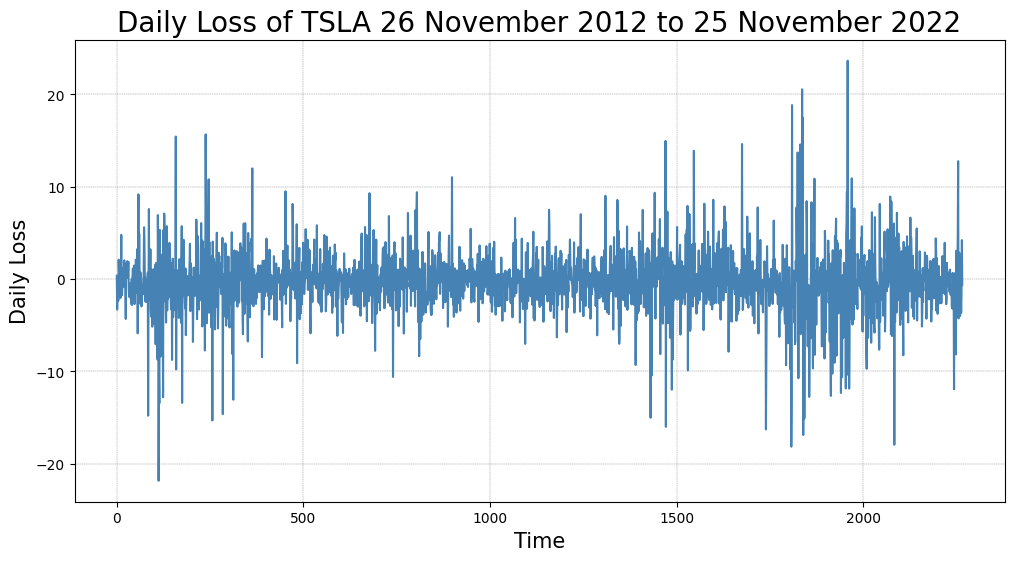

In [4]:
# plot the loss data
plt.figure(figsize=(12, 6))
plt.plot(prices_arr, color = '#4682b4')
plt.ylabel(r"$S_t$ (adjusted closing price)", fontsize = 15)
plt.xlabel('Time', fontsize=15)
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.gcf().set_facecolor("white")
plt.title(r"Adjusted Close Price of TSLA 26 November 2012 to 25 November 2022", fontsize=20)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(x_training_arr, color = '#4682b4')
plt.ylabel('Daily Loss', fontsize=15)
plt.xlabel('Time', fontsize=15)
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.gcf().set_facecolor("white")
plt.title(r"Daily Loss of TSLA 26 November 2012 to 25 November 2022", fontsize=20)
plt.show()

In [5]:
# the function to fit a GARCH model with constant mean and normal innovations using training data
def fit_arch(x, mean='constant', p=1, q=1, dist='normal'):
    model = arch_model(x, mean=mean, p=p, q=q, dist=dist)

    # fit the model
    res = model.fit(update_freq=3)

    # show the fitting results
    print(res)

    # record the estimated parameter values
    mu_hat = res.params['mu']
    alpha_0 = res.params['omega']
    alpha_1 = res.params['alpha[1]']
    beta_1 = res.params['beta[1]']
    params_dict = {'mu_hat': mu_hat, 'alpha_0': alpha_0, 'alpha_1': alpha_1, 'beta_1': beta_1}

    # construct arrays for the process
    T = len(x)
    loss_arr_1 = np.array(x)
    epsilon_arr = loss_arr_1 - mu_hat
    z_arr = np.zeros(T)
    sig_arr = np.zeros(T)

    # compute the estimates sigma values, and the values of the standardised residuals
    for i in range(T):
        if i == 0:
            sig_lag = np.var(loss_arr_1)
            X_lag = np.mean(loss_arr_1)
        else:
            sig_lag = sig_arr[i-1]
            X_lag = loss_arr_1[i-1]

        sig_arr[i] = alpha_0 + alpha_1*(X_lag - mu_hat)**2 + beta_1*sig_lag
        z_arr[i] = epsilon_arr[i] / np.sqrt(sig_arr[i])

    return params_dict, z_arr, sig_arr


# the function to first fit a GARCH model with training data, and compute the inferrred values for the testing data
def fit_testing_values(x_training, x_testing, mean='constant', p=1, q=1, dist='normal'):
    # obtain the estimated parameters based on the training data
    params_dict, z_arr_train, sig_arr_train = fit_arch(x_training, mean=mean, p=p, q=q, dist=dist)

    # compute the fitted values for the testing data
    T = len(x_testing)
    loss_arr_1 = np.array(x_testing)
    epsilon_arr = loss_arr_1 - params_dict['mu_hat']
    z_arr = np.zeros(T)
    sig_arr = np.zeros(T)

    # compute the estimates sigma values, and the values of the standardised residuals
    for i in range(T):
        if i == 0:
            sig_lag = sig_arr_train[-1]
            X_lag = np.array(x_training)[-1]
        else:
            sig_lag = sig_arr[i-1]
            X_lag = loss_arr_1[i-1]

        sig_arr[i] = params_dict['alpha_0'] + params_dict['alpha_1']*(X_lag - params_dict['mu_hat'])**2 + params_dict['beta_1']*sig_lag
        z_arr[i] = epsilon_arr[i] / np.sqrt(sig_arr[i])

    return params_dict, z_arr, sig_arr

In [6]:
params_dict, z_arr_train, sig_arr_train = fit_arch(x_training_arr, mean='constant', p=1, q=1, dist='normal')
params_dict, z_arr_test, sig_arr_test = fit_testing_values(x_training_arr, x_testing_arr, mean='constant', p=1, q=1, dist='normal')
# params_dict contains the values of the parameter
print(params_dict)

Iteration:      3,   Func. Count:     20,   Neg. LLF: 5878.970821966002
Iteration:      6,   Func. Count:     38,   Neg. LLF: 5864.248106120973
Iteration:      9,   Func. Count:     57,   Neg. LLF: 5854.909254345244
Optimization terminated successfully    (Exit mode 0)
            Current function value: 5854.9091189006
            Iterations: 11
            Function evaluations: 67
            Gradient evaluations: 11
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5854.91
Distribution:                  Normal   AIC:                           11717.8
Method:            Maximum Likelihood   BIC:                           11740.7
                                        No. Observations:                 2266
Date:                Thu

In [7]:
mu_arr_train = np.array([params_dict['mu_hat'] for _ in range(len(x_training_arr))])
mu_arr_test = np.array([params_dict['mu_hat'] for _ in range(len(x_testing_arr))])

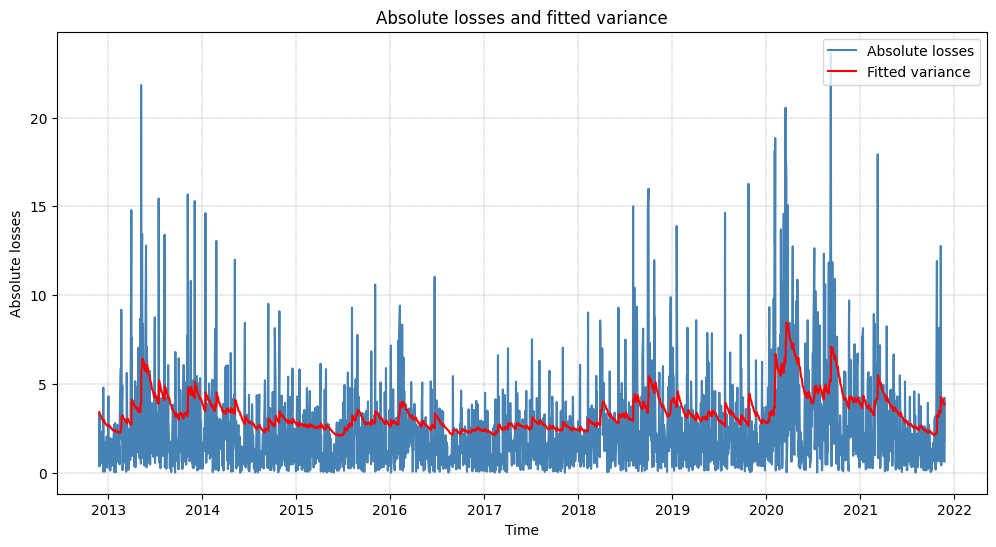

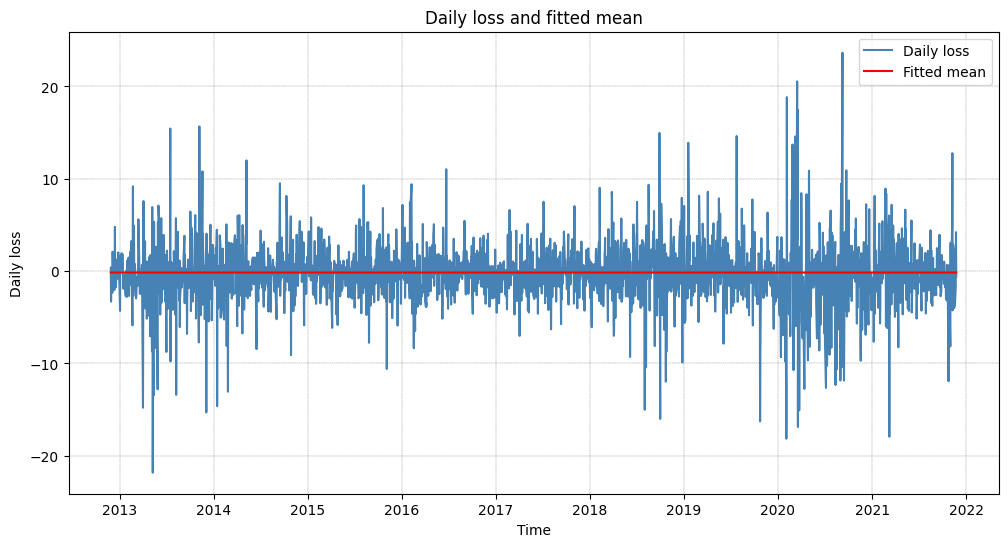

In [9]:
# Plot the absolute returns and fitted volatilities
# Use hexcode #4682B4 for the color of the absolute returns and #FF6347 for the color of the fitted volatilities
plt.figure(figsize=(12, 6))
plt.plot(time_training, abs(x_training_arr), label="Absolute losses", color="#4682B4")
plt.plot(time_training, np.sqrt(sig_arr_train), label="Fitted variance", color="red")
plt.title("Absolute losses and fitted variance")
plt.xlabel("Time")
plt.ylabel("Absolute losses")
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(time_training, x_training_arr, label="Daily loss", color="#4682B4")
plt.plot(time_training, mu_arr_train, label="Fitted mean", color="red")
plt.title("Daily loss and fitted mean")
plt.xlabel("Time")
plt.ylabel("Daily loss")
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<ipython-input-8-fe8451ec744e>:4: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(time_training, mu_arr_train, color='blue', label="$\hat{\mu}_t$")


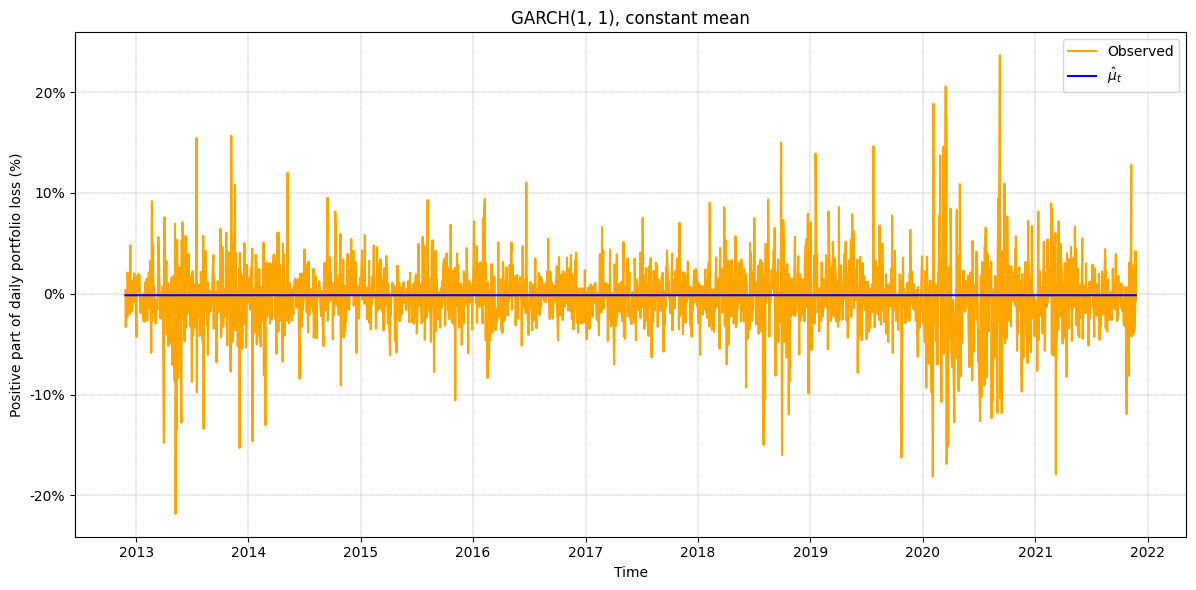

In [ ]:
# Plot the training time series against the estimated mean of GARCH process
plt.figure(figsize=(12, 6))
plt.plot(time_training, x_training_arr, color='orange', label="Observed")
plt.plot(time_training, mu_arr_train, color='blue', label="$\hat{\mu}_t$")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# Adding title, labels, and legend
plt.title("GARCH(1, 1), constant mean")
plt.xlabel("Time")
plt.ylabel("Positive part of daily portfolio loss (%)")
plt.legend()

plt.tight_layout()  # Adjust layout to fit everything nicely


def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<ipython-input-9-840499e0cbae>:4: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(time_training, np.sqrt(sig_arr_train), color='blue', label="$\hat{\sigma}_t^2$")


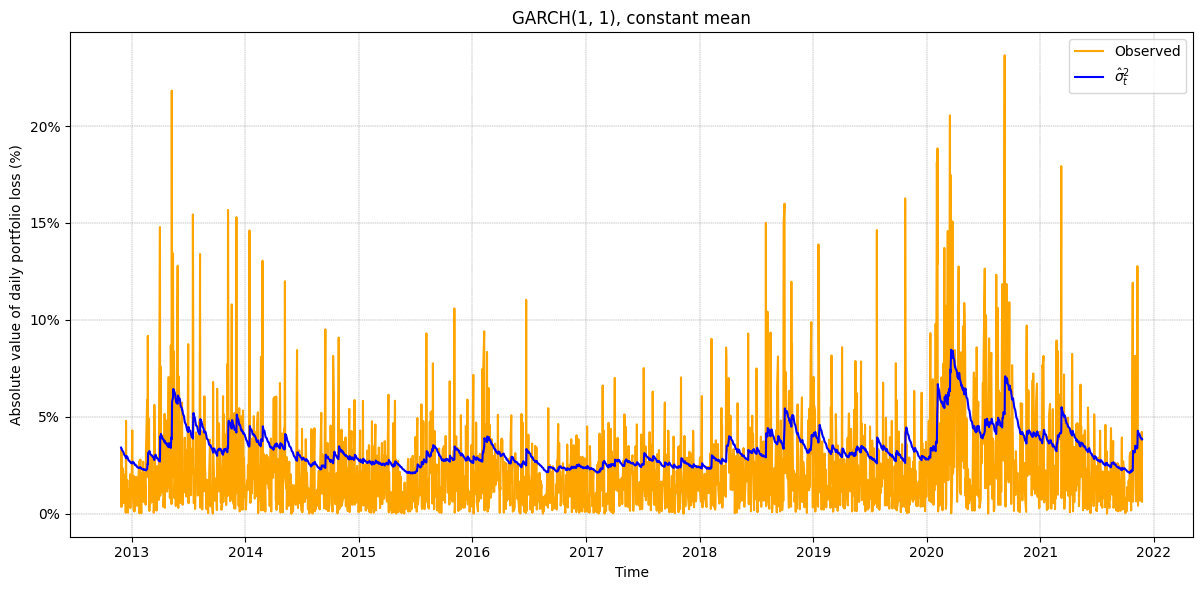

In [ ]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(time_training, abs(x_training_arr), color='orange', label="Observed")
plt.plot(time_training, np.sqrt(sig_arr_train), color='blue', label="$\hat{\sigma}_t^2$")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# Adding title, labels, and legend
plt.title("GARCH(1, 1), constant mean")
plt.xlabel("Time")
plt.ylabel("Absolute value of daily portfolio loss (%)")
plt.legend()

plt.tight_layout()  # Adjust layout to fit everything nicely


def y_fmt(x, y):
    return f"{x:.0f}%"


plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

plt.show()

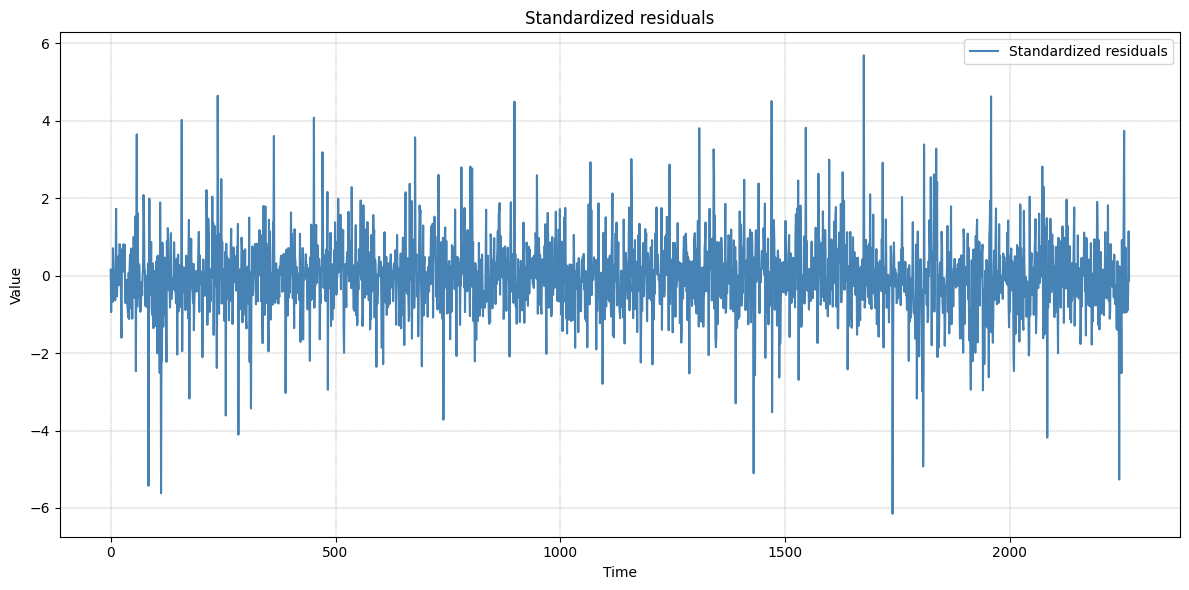

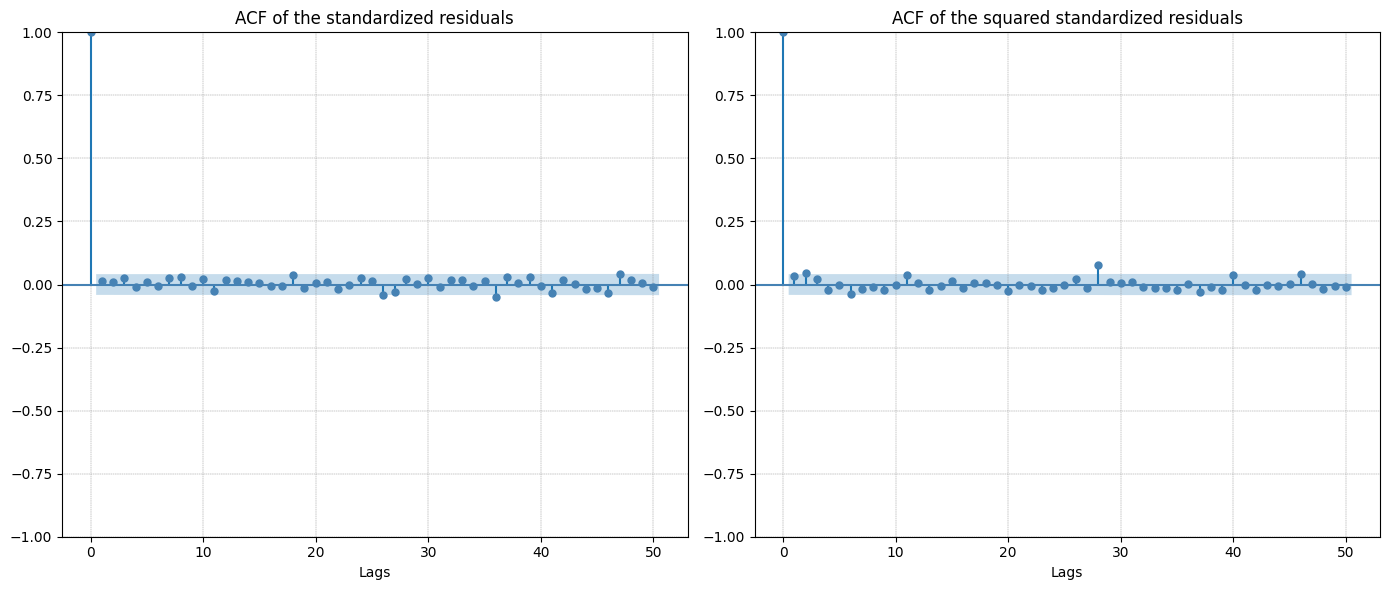

In [ ]:
# Plot the standardized residuals
plt.figure(figsize=(12, 6))
plt.plot(z_arr_train, color="#4682b4", label="Standardized residuals")
plt.title("Standardized residuals")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.show()

# Plot the ACF of the standardized residuals and their squared values
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot ACF of standardized residuals
sm.graphics.tsa.plot_acf(z_arr_train, lags=50, ax=ax[0], title="ACF of the standardized residuals", color="#4682b4")
ax[0].set_xlabel("Lags")  # Set x-axis label for the first subplot

# Plot ACF of squared standardized residuals
sm.graphics.tsa.plot_acf((z_arr_train)**2, lags=50, ax=ax[1], title="ACF of the squared standardized residuals", color="#4682b4")
ax[1].set_xlabel("Lags")  # Set x-axis label for the second subplot

# Adjust layout and style
plt.tight_layout()
ax[0].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
ax[1].grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# Show the plot
plt.show()

/Users/lizhengyang/miniconda3/envs/ic_math/lib/python3.12/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


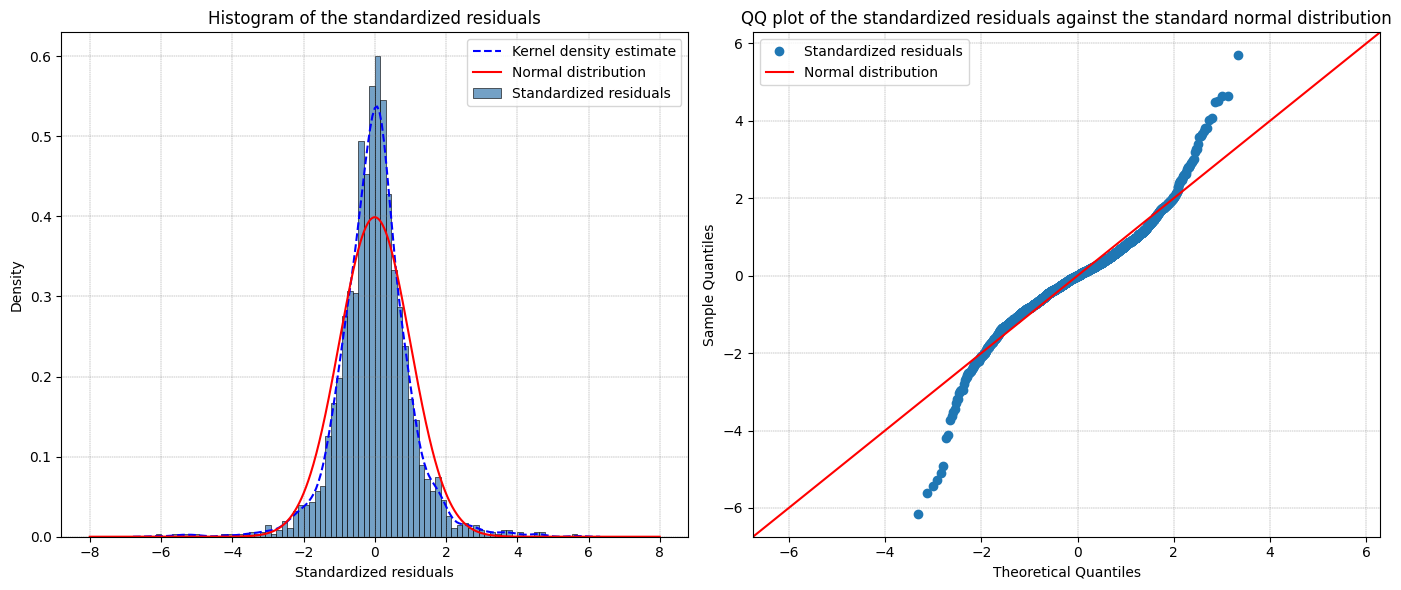

In [ ]:
# Histogram of the standardized residuals, its kernel density estimate, and the standard normal density plotted side by side with QQ plot of the standardized residuals against the standard normal distribution. we take normal 0, 1
# Histogram of the standardized residuals
plt.figure(figsize=(14, 6))

plt.subplot(121)
sns.histplot(z_arr_train, stat="density", color="#4682b4", label="Standardized residuals", legend=True)
sns.kdeplot(z_arr_train, color="blue", linestyle="--",label="Kernel density estimate", legend=True)
plt.title("Histogram of the standardized residuals")
plt.xlabel("Standardized residuals")
plt.ylabel("Density")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# add the normal 0, 1 density
x = np.linspace(-8, 8, 1000)
y = norm.pdf(x, 0, 1)
plt.plot(x, y, color="red", label="Normal distribution")
plt.legend()

# QQ plot of the standardized residuals against the standard normal distribution
plt.subplot(122)
sm.qqplot(z_arr_train, line="45", ax=plt.gca(), color ="#4682b4")
plt.title("QQ plot of the standardized residuals against the standard normal distribution")
plt.legend(["Standardized residuals", "Normal distribution", "Kernel density estimate"])
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.tight_layout()
plt.show()

In [ ]:
# extra fittings
# Fit a student t distribution to the standardised residuals z_arr_train

def log_likelihood_t(X, k):
    n = len(X)
    return - n / 2 * np.log(k) - n * np.log(beta(1 / 2, k / 2)) - (k + 1) / 2 * np.sum(np.log(1 + X**2 / k))


obj_func = lambda k: -1 * log_likelihood_t(z_arr_train, k)
k0 = 1 # initial guess
print("Initial objective function value: " + str(obj_func(k0)))
bnds = ((0.01, None),)
sol = minimize(obj_func, k0, method = 'SLSQP', bounds = bnds, options={'disp': True})
k = sol.x[0]
print("Estimate of k: " + str(sol.x[0]))
print("Final objective function value: " + str(obj_func(sol.x[0])))

Initial objective function value: 3604.1875691165537
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3131.3298849880102
            Iterations: 10
            Function evaluations: 27
            Gradient evaluations: 10
Estimate of k: 9.72817359122669
Final objective function value: 3131.3298849880102


/Users/lizhengyang/miniconda3/envs/ic_math/lib/python3.12/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


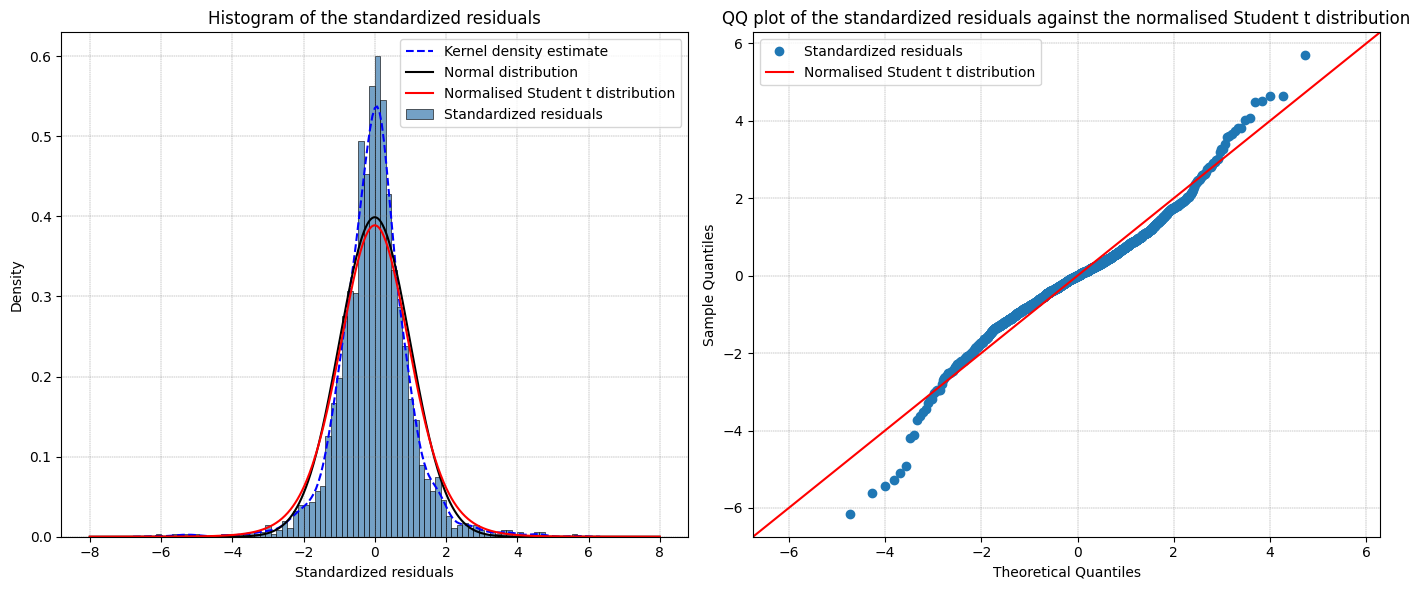

In [ ]:
# plot fitted t distribution
plt.figure(figsize=(14, 6))

plt.subplot(121)
sns.histplot(z_arr_train, stat="density", color="#4682b4", label="Standardized residuals", legend=True)
sns.kdeplot(z_arr_train, color="blue", linestyle="--",label="Kernel density estimate", legend=True)
plt.title("Histogram of the standardized residuals")
plt.xlabel("Standardized residuals")
plt.ylabel("Density")
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

# add the normal 0, 1 density
x = np.linspace(-8, 8, 1000)
y = norm.pdf(x, 0, 1)
plt.plot(x, y, color="black", label="Normal distribution")
y_2 = t.pdf(x, df=k)
plt.plot(x, y_2, color='red', label='Normalised Student t distribution')
plt.legend()

# QQ plot of the standardized residuals against the standard normal distribution
plt.subplot(122)
sm.qqplot(z_arr_train, t, distargs=(k,), line ='45', ax=plt.gca(), color ="#4682b4")
# sm.qqplot(z_arr_train, line="45", ax=plt.gca(), color ="#4682b4")
plt.title("QQ plot of the standardized residuals against the normalised Student t distribution")
plt.legend(["Standardized residuals", "Normalised Student t distribution", "Kernel density estimate"])
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.tight_layout()
plt.show()

In [ ]:
# GPD fitting
# Plot the Mean excess function for different cut-off thresholds v
v = np.linspace(0, 50, 100) # some values of v
excess_mean = []

for vv in v:
    excess_mean.append(np.sum((z_arr_train - vv) * (z_arr_train > vv)) / np.sum(z_arr_train > vv))

<ipython-input-14-80eea3e8fa92>:7: RuntimeWarning: invalid value encountered in scalar divide
  excess_mean.append(np.sum((z_arr_train - vv) * (z_arr_train > vv)) / np.sum(z_arr_train > vv))


In [ ]:
v = np.linspace(0, 50, 1000)  # Threshold values
excess_mean = []

for vv in v:
    exceedances_count = np.sum(z_arr_train > vv)  # Count exceedances
    if exceedances_count > 0:
        # Compute mean excess for valid cases
        excess_mean.append(np.sum((z_arr_train - vv) * (z_arr_train > vv)) / exceedances_count)
    else:
        # Handle case with no exceedances
        excess_mean.append(np.nan)  # Append NaN for thresholds with no exceedances

In [ ]:
plt.style.use('ggplot')

Text(0.5, 0, '$v$')

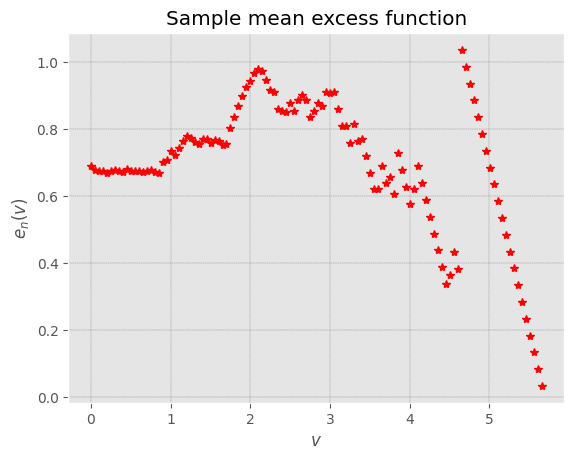

In [ ]:
plt.plot(v, excess_mean, 'r*')
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.title("Sample mean excess function")
plt.ylabel("$e_n(v)$")
plt.xlabel("$v$")

Text(0.5, 0, '$v$')

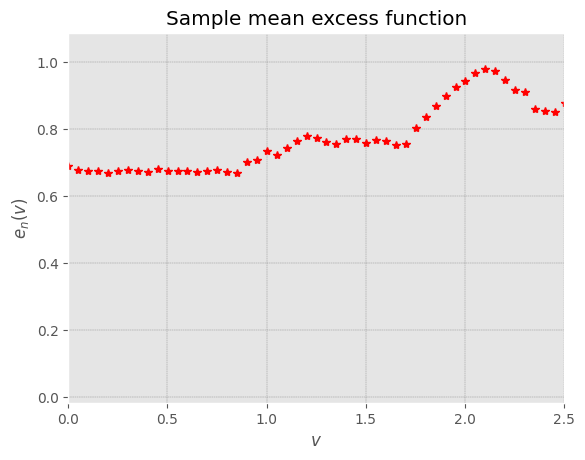

In [ ]:
# Plot the Mean Excess Function
plt.plot(v, excess_mean, 'r*')
plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")
plt.title("Sample mean excess function")
plt.xlim(0, 2.5)
plt.ylabel("$e_n(v)$")
plt.xlabel("$v$")

In [ ]:
u = 1  # choose u (tried choosing u = 4, and only got 1 exceedance) 
z_exceed = z_arr_train[z_arr_train > u]-u


# definte loglikelihood for parameters of GPD
def GPD_loglikelihood(z_exceed, xi, beta):
    return -len(z_exceed) * np.log(beta) - (1 + 1/xi) * np.sum(np.log(1 + xi * z_exceed / beta))


# fit the parameters xi and beta
objfun = lambda theta : -1 * GPD_loglikelihood(z_exceed, theta[0], theta[1])  # theta[0] represents xi and theta[1] represents beta

theta0 = [1, 1]  # initial guess
print("Initial objective function value: " + str(objfun(theta0)))

bnds = ((0.01,20), (1e-6,20)) # individual bound on each parameter

sol = minimize(objfun,theta0,method='SLSQP',bounds=bnds, options={'disp': True})
xi_hat = sol.x[0]
beta_hat = sol.x[1]
print("Estimate of xi: " + str(sol.x[0]))
print("Estimate of beta: " + str(sol.x[1]))

Initial objective function value: 231.51227868870586
Optimization terminated successfully    (Exit mode 0)
            Current function value: 168.4367734970465
            Iterations: 13
            Function evaluations: 46
            Gradient evaluations: 13
Estimate of xi: 0.07626094743082996
Estimate of beta: 0.6798097373852958


In [ ]:
# Plot the fitted GPD against the empirical value of threshold exceedances (z_exceed)
def GPD_cdf(x, xi, beta): # Implement the CDF of GPD
    if xi == 0:
        return 1 - np.exp(-x/beta)
    else:
        return 1 - (1 + xi * x / beta) ** (-1/xi)

xx = np.linspace(0, 250, 10000) # For plotting the theoretical, fitted GPD

# Empirical CDF functionality from the "statsmodels" package
empirical_cdf_obj = sm.distributions.empirical_distribution.ECDF((z_exceed.flatten()))

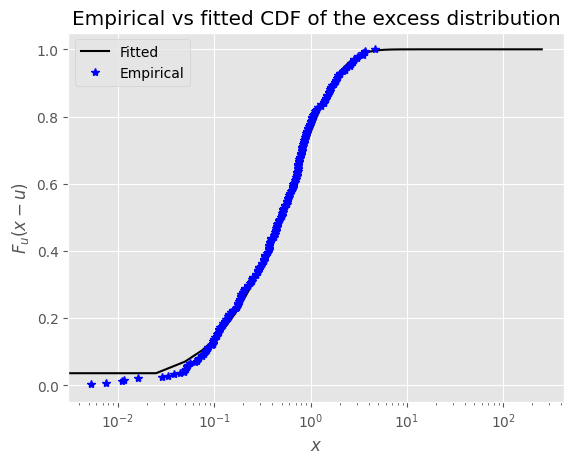

In [ ]:
# plt.style.use('ggplot')
fig, ax = plt.subplots()
ax.plot(xx, GPD_cdf(xx, sol.x[0], sol.x[1]), 'k-', label='Fitted') # Plot the CDF of fitted GPD
ax.plot(z_exceed, empirical_cdf_obj(z_exceed), 'b*', label='Empirical') # Plot the empirical CDF of Y, the excess claim value above u

ax.legend()
ax.set_xscale('log')
ax.set_title('Empirical vs fitted CDF of the excess distribution')
ax.set_ylabel('$F_{u}(x-u)$')
ax.set_xlabel('$x$')
plt.show()

xi = float(sol.x[0])
pareto_beta = float(sol.x[1])

In [ ]:
# Compute the risk measures
def risk_measure_test(mu_arr, sig_arr, mode='normal', alpha=0.95, v=None, u=None, beta=None, xi=None):
    VaR_list = []
    ES_list = []
    for i in range(len(mu_arr)):
        if mode == 'normal':
            q_z = norm.ppf(alpha)
            ES_z = norm.pdf(norm.ppf(alpha)) / (1 - alpha)
            VaR_L = mu_arr[i] + np.sqrt(sig_arr[i]) * q_z
            ES_L = mu_arr[i] + np.sqrt(sig_arr[i]) * ES_z
            VaR_list.append(VaR_L)
            ES_list.append(ES_L)

        if mode == 't':
            q_z = np.sqrt((v-2)/v) * t.ppf(alpha, v)
            ES_z = np.sqrt((v-2)/v) * (t.pdf(t.ppf(alpha, v), v) * ((v + t.ppf(alpha, v)**2)/(v-1)) / (1-alpha))
            VaR_L = mu_arr[i] + np.sqrt(sig_arr[i]) * q_z
            ES_L = mu_arr[i] + np.sqrt(sig_arr[i]) * ES_z
            VaR_list.append(VaR_L)
            ES_list.append(ES_L)

        if mode == 'pareto':
            if i == 1:
                empirical_cdf_obj = sm.distributions.empirical_distribution.ECDF(((z_arr_train).flatten()))
            else:
                empirical_cdf_obj = sm.distributions.empirical_distribution.ECDF(((np.concatenate((z_arr_train, z_arr_test[0:i]), axis=None)).flatten()))
            q_z = u + (beta/xi) * (((1-alpha)/(1 - empirical_cdf_obj(u)))**(-xi) - 1)
            ES_z = q_z / (1-xi) + (beta - xi*u) / (1-xi)
            VaR_L = mu_arr[i] + np.sqrt(sig_arr[i]) * q_z
            ES_L = mu_arr[i] + np.sqrt(sig_arr[i]) * ES_z
            VaR_list.append(VaR_L)
            ES_list.append(ES_L)

    return np.array(VaR_list), np.array(ES_list)

In [ ]:
# 95 level
VaR_95_normal, ES_95_normal = risk_measure_test(mu_arr_test, sig_arr_test, mode='normal', alpha=0.95)
VaR_95_t, ES_95_t = risk_measure_test(mu_arr_test, sig_arr_test, mode='t', alpha=0.95, v=k)
VaR_95_pareto, ES_95_pareto = risk_measure_test(mu_arr_test, sig_arr_test, mode='pareto', alpha=0.95, u=u, beta=beta_hat, xi=xi_hat)
# 99 level
VaR_99_normal, ES_99_normal = risk_measure_test(mu_arr_test, sig_arr_test, mode='normal', alpha=0.99)
VaR_99_t, ES_99_t = risk_measure_test(mu_arr_test, sig_arr_test, mode='t', alpha=0.99, v=k)
VaR_99_pareto, ES_99_pareto = risk_measure_test(mu_arr_test, sig_arr_test, mode='pareto', alpha=0.99, u=u, beta=beta_hat, xi=xi_hat)

In [ ]:
# Plotting function
def plot_risk_measures(VaR_arr, ES_arr, VaR_arr_2=None, ES_arr_2=None, time_arr=time_testing, x_arr=x_testing_arr, name='Standard normal', level='95', ylim=15):
    if level == 'both':
        plt.figure(figsize=(12, 6))
        plt.plot(time_arr, x_arr, label="Observed", linewidth=1, color="orange")
        plt.plot(time_arr, VaR_arr, label=f"95% VaR", linewidth=1, color="red")
        plt.plot(time_arr, ES_arr, label=f"95% ES", linewidth=1, color="red", linestyle="--")
        plt.plot(time_arr, VaR_arr_2, label=f"99% VaR", linewidth=1, color="blue")
        plt.plot(time_arr, ES_arr_2, label=f"99% ES", linewidth=1, color="blue", linestyle="--")
        plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

        # Adding title, labels, and legend
        plt.title(f"Risk Measures under GARCH(1, 1), constant mean (Z follows {name} distribution)")
        plt.xlabel("Time")
        plt.ylabel("Positive part of daily loss (%)")
        plt.legend()
        plt.ylim(0, ylim)
        plt.tight_layout()  # Adjust layout to fit everything nicely

        def y_fmt(x, y):
            return f"{x:.0f}%"

        plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

        plt.show()

    else:
        plt.figure(figsize=(12, 6))
        plt.plot(time_arr, x_arr, label="Observed", linewidth=1, color="orange")
        plt.plot(time_arr, VaR_arr, label=f"{level}% VaR", linewidth=1, color="red")
        plt.plot(time_arr, ES_arr, label=f"{level}% ES", linewidth=1, color="red", linestyle="--")
        plt.grid(True, which='both', linestyle='--', linewidth=0.3, color="gray")

        # Adding title, labels, and legend
        plt.title(f"Risk Measures under GARCH(1, 1), constant mean (Z follows {name} distribution)")
        plt.xlabel("Time")
        plt.ylabel("Positive part of daily loss (%)")
        plt.legend()
        plt.ylim(0, ylim)
        plt.tight_layout()  # Adjust layout to fit everything nicely

        def y_fmt(x, y):
            return f"{x:.0f}%"

        plt.gca().yaxis.set_major_formatter(tick.FuncFormatter(y_fmt))

        plt.show()

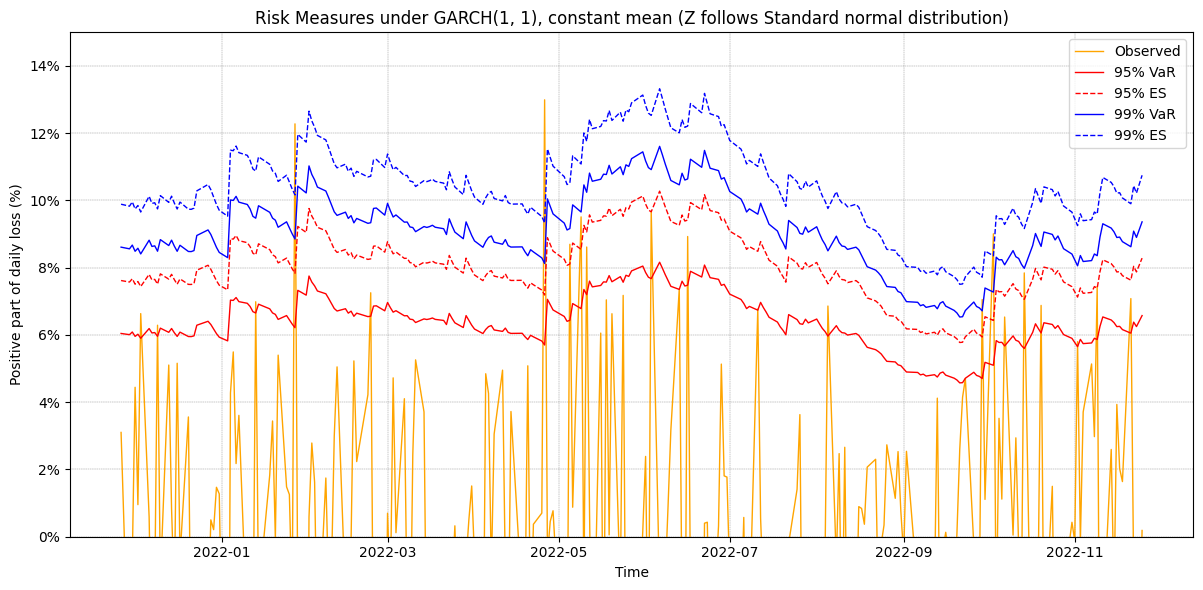

In [ ]:
plot_risk_measures(VaR_95_normal, ES_95_normal, VaR_arr_2=VaR_99_normal, ES_arr_2=ES_99_normal, name='Standard normal', level='both')

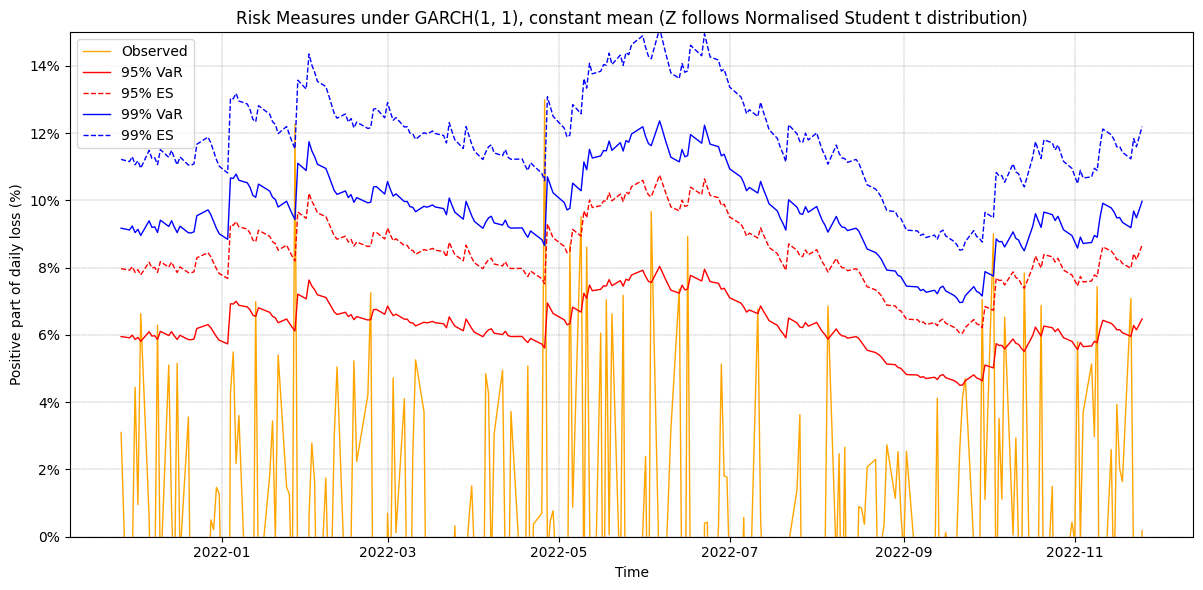

In [ ]:
plot_risk_measures(VaR_95_t, ES_95_t, VaR_arr_2=VaR_99_t, ES_arr_2=ES_99_t, name='Normalised Student t', level='both')

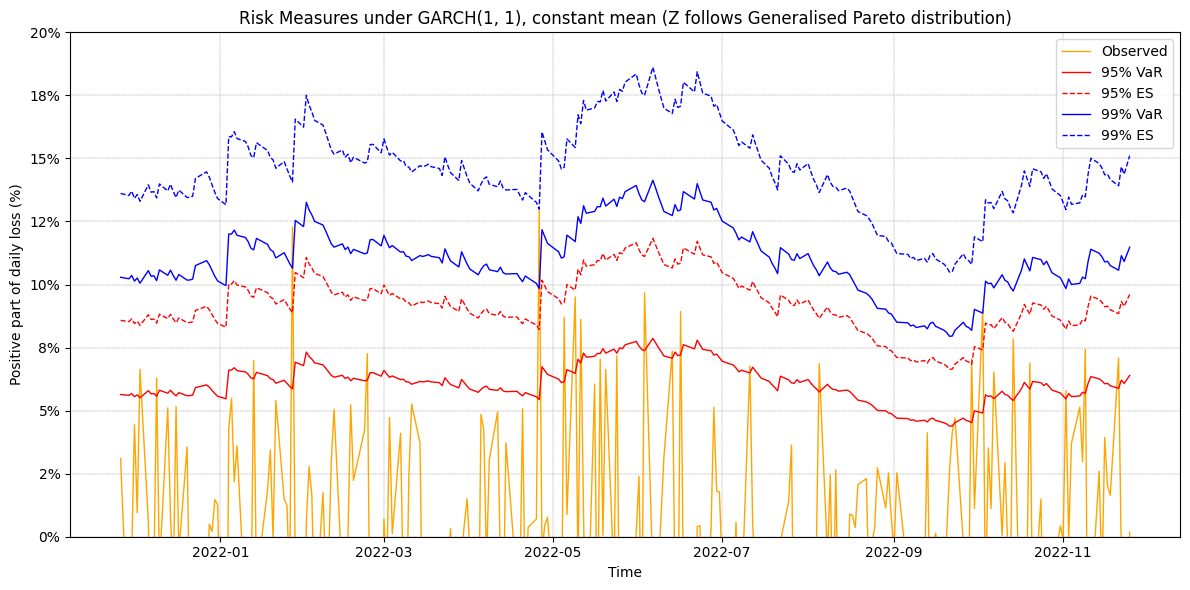

In [ ]:
plot_risk_measures(VaR_95_pareto, ES_95_pareto, VaR_arr_2=VaR_99_pareto, ES_arr_2=ES_99_pareto, name='Generalised Pareto', level='both', ylim=20)

In [ ]:
# VaR test
# function for conducting hypothesis tests with respect to VaR
def hypothesis_test_VaR(loss_arr, VaR_arr, q=0.95, mode='unconditional'):
    """
    Function for conducting hypothesis tests with respect to VaR.
    Input:
    loss_arr: the numpy array of loss of the portfolio (length: N).
    VaR_arr: the numpy array of VaR using a rolling window method (length: N-T).
    T: size of rolling window.
    q: the quantile level for the test.
    mode: 'unconditional' for unconditional coverage test, and 'independence' for 
    independence test.
    Output:
    p_value: the p_value of the test
    """
    loss_reduced = loss_arr
    # VaR violations
    I_arr = np.array([1 if a > b else 0 for a, b in zip(loss_reduced, VaR_arr)])
    violation_tuple = tuple((np.sum(I_arr), len(loss_reduced), np.sum(I_arr)/len(loss_reduced)))

    # unconditional coverage
    if mode == 'unconditional':
        pi_hat = np.sum(I_arr) / len(I_arr)
        val_tmp = 1
        for p in range(len(I_arr)):
            val_tmp = val_tmp * (q**(1-I_arr[p]) * (1-q)**(I_arr[p])) / ((1-pi_hat)**(1-I_arr[p]) * pi_hat**(I_arr[p]))
        LR_uc = -2 * np.log(val_tmp)
        p_value = 1 - chi2.cdf(LR_uc, 1)

    return violation_tuple, LR_uc, p_value

In [ ]:
# unconditional coverage test of 95% level
violation_tuple1, LR_uc1, p_list1 = hypothesis_test_VaR(x_testing_arr, VaR_95_normal, q=0.95)
violation_tuple2, LR_uc2, p_list2 = hypothesis_test_VaR(x_testing_arr, VaR_95_t, q=0.95)
violation_tuple3, LR_uc3, p_list3 = hypothesis_test_VaR(x_testing_arr, VaR_95_pareto, q=0.95)

# unconditional coverage test of 99% level
violation_tuple4, LR_uc4, p_list4 = hypothesis_test_VaR(x_testing_arr, VaR_99_normal, q=0.99)
violation_tuple5, LR_uc5, p_list5 = hypothesis_test_VaR(x_testing_arr, VaR_99_t, q=0.99)
violation_tuple6, LR_uc6, p_list6 = hypothesis_test_VaR(x_testing_arr, VaR_99_pareto, q=0.99)

In [ ]:
violation_tuple1, LR_uc1, p_list1

((22, 252, 0.0873015873015873), 6.097225401327237, 0.013539430301558353)

In [ ]:
violation_tuple2, LR_uc2, p_list2

((23, 252, 0.09126984126984126), 7.341164867807004, 0.006739315415394631)

In [ ]:
violation_tuple3, LR_uc3, p_list3

((23, 252, 0.09126984126984126), 7.341164867807004, 0.006739315415394631)

In [ ]:
violation_tuple4, LR_uc4, p_list4

((4, 252, 0.015873015873015872), 0.7450809522744105, 0.3880381133603764)

In [ ]:
violation_tuple5, LR_uc5, p_list5

((3, 252, 0.011904761904761904), 0.08704443664799089, 0.7679687153509291)

In [ ]:
violation_tuple6, LR_uc6, p_list6

((3, 252, 0.011904761904761904), 0.08704443664799089, 0.7679687153509291)